Extracted File Name: nigeria-cog-chirps-v2.0.1981.01.01


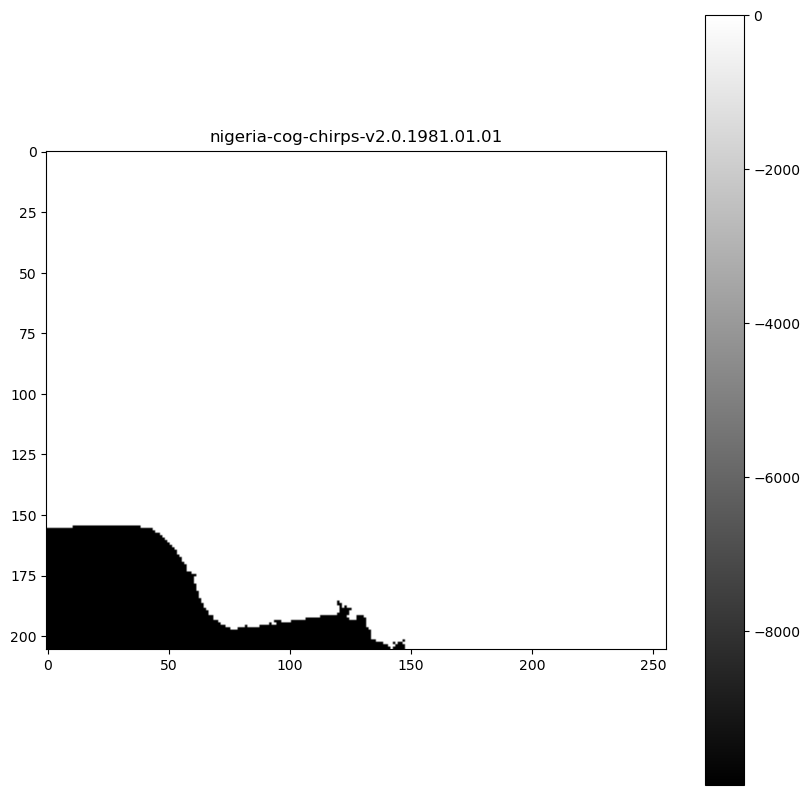

In [1]:
import os
from azure.identity import DefaultAzureCredential
from azure.storage.blob import ContainerClient
from rio_stac import create_stac_item
from rasterio.io import MemoryFile
import json
from urllib.parse import urlparse, unquote
import matplotlib.pyplot as plt

blob_domain = "https://mpcpstorageaccount.blob.core.windows.net"
container_name = "processed-cogs"

credential = DefaultAzureCredential()

container_client = ContainerClient(
    account_url=blob_domain,
    container_name=container_name,
    credential=credential
)

def display_tif_from_blob(blob_client, title):
    blob_data = blob_client.download_blob().readall()
    
    with MemoryFile(blob_data) as memfile:
        with memfile.open() as dataset:
            plt.figure(figsize=(10, 10))
            plt.imshow(dataset.read(1), cmap='gray')
            plt.title(title)
            plt.colorbar()
            plt.show()

# Get a blob client for the specific blob
# Construct the directory path
year = "1981"
directory_path = f"{year}/"

# Get just the first blob by using next() and limiting the iterator
first_blob = next(container_client.list_blobs(name_starts_with=directory_path))

blob_client = container_client.get_blob_client(first_blob.name)

# Extract filename from blob name
filename = os.path.basename(first_blob.name)
file_name = filename.replace('.tif', '')

print(f"Extracted File Name: {file_name}")

display_tif_from_blob(blob_client, file_name)

In [2]:
from datetime import datetime, timezone
def extract_metadata_from_filename_chirps(filename: str) -> dict:
    """
    Extracts key metadata from a CHIRPS filename using regular expressions.
    The filename is of the format: nigeria-cog-chirps-v2.0.1981.01.01

    Args:
        filename (str): The filename to parse.

    Returns:
        dict: A dictionary containing the extracted metadata.
    """
    try:
        parsed_list = filename.split("-")
        product_type = parsed_list[2]
        version_year_list = parsed_list[3].split(".")
        version = '.'.join(version_year_list[0:2])
        date = datetime.strptime("-".join(version_year_list[2:]), '%Y-%m-%d')
        date = date.replace(tzinfo=timezone.utc) 
        creation_date = datetime.now(timezone.utc)

        # create a dictionary to organise all of the extracted metadata:
        metadata = {
            "product_type": product_type,
            "version": version,
            "date": date,
            "creation_date": creation_date
        }
        return metadata
    except Exception as e:
        print("Failed to extract metadata due to {e}")
        return None
    

metadata_from_filename = extract_metadata_from_filename_chirps(file_name)
print(metadata_from_filename)

{'product_type': 'chirps', 'version': 'v2.0', 'date': datetime.datetime(1981, 1, 1, 0, 0, tzinfo=datetime.timezone.utc), 'creation_date': datetime.datetime(2025, 10, 25, 9, 59, 28, 615980, tzinfo=datetime.timezone.utc)}


In [3]:
from rio_stac import create_stac_item
from rasterio.io import MemoryFile
import json
from urllib.parse import urlparse, unquote

def create_stac_item_from_cog(blob_client, filename, blob_domain, container_name):
    """
    Create a basic STAC Item for CHIRPS data using rio-stac with proper spatial handling
    
    Args:
        url (str): URL to the COG file
        
    Returns:
        pystac.Item: STAC Item with basic metadata and correct spatial information
    """
    blob_data = blob_client.download_blob().readall()
    blob_properties = blob_client.get_blob_properties()
    blob_size = blob_properties.size
    item_id = filename.replace('.tif', '')

    try:
        with MemoryFile(blob_data) as memfile:
            with memfile.open() as dataset:
                # Create base STAC item from rasterio dataset calling create_stac_item from rio_stac
                stac_item = create_stac_item(
                    source = dataset, 
                    id = item_id,
                    asset_name = 'data',
                    asset_href = f"{blob_domain}/{container_name}/{year}/{filename}",
                    with_proj = True,
                    with_raster = True, 
                    properties = {
                        'datetime': None,
                        'raster:bands': [
                                {
                                    'nodata': dataset.nodata,  # Value representing no data in the raster
                                    'data_type': dataset.dtypes[0],  # Data type of the raster (e.g., uint16)
                                    'spatial_resolution': dataset.res[0]  # Spatial resolution of the raster in meters
                                }
                            ],
                            'file:size': blob_size  # Size of the file in bytes
                    },
                    extensions=[
                            'https://stac-extensions.github.io/file/v2.1.0/schema.json'  # Add the file extension schema for additional metadata
                        ]
                    )
                return stac_item
    except Exception as e:
        raise Exception(f"Failed to extract metadata due to {e}")

    
year = "1981"
directory_path = f"{year}/"
blob_domain = "https://mpcpstorageaccount.blob.core.windows.net"
container_name = "processed-cogs"

# Get just the first blob by using next() and limiting the iterator
# for iterator in container_client.list_blobs(name_starts_with=directory_path):
#     blob_client = container_client.get_blob_client(iterator.name)
#     filename = os.path.basename(iterator.name)
    
#     create_stac_item_from_cog(blob_client, filename, blob_domain, container_name)

first_blob = next(container_client.list_blobs(name_starts_with=directory_path))
blob_client = container_client.get_blob_client(first_blob.name)

# Extract filename from blob name
filename = os.path.basename(first_blob.name)
stac_item = create_stac_item_from_cog(blob_client, filename, blob_domain, container_name)
print(json.dumps(stac_item.to_dict(), indent=2))

{
  "type": "Feature",
  "stac_version": "1.1.0",
  "stac_extensions": [
    "https://stac-extensions.github.io/file/v2.1.0/schema.json",
    "https://stac-extensions.github.io/projection/v1.1.0/schema.json",
    "https://stac-extensions.github.io/raster/v1.1.0/schema.json"
  ],
  "id": "nigeria-cog-chirps-v2.0.1981.01.01",
  "geometry": {
    "type": "Polygon",
    "coordinates": [
      [
        [
          2.3163880000000034,
          3.8533498465180394
        ],
        [
          15.116388190734867,
          3.8533498465180394
        ],
        [
          15.116388190734867,
          14.15335
        ],
        [
          2.3163880000000034,
          14.15335
        ],
        [
          2.3163880000000034,
          3.8533498465180394
        ]
      ]
    ]
  },
  "bbox": [
    2.3163880000000034,
    3.8533498465180394,
    15.116388190734867,
    14.15335
  ],
  "properties": {
    "datetime": "2025-10-25T09:59:28.876652Z",
    "raster:bands": [
      {
        "no

In [4]:
import pystac
def enhance_stac_item_with_metadata(stac_item, metadata_from_filename):
    """
    Enhances a STAC Item with additional metadata from CHIRPS filename.
    
    Args:
        stac_item (pystac.Item): Existing STAC Item created by rio-stac
        metadata_from_filename (dict): Metadata extracted from filename
        
    Returns:
        pystac.Item: Enhanced STAC Item

        metadata = {
            "product_type": product_type,
            "version": "version",
            "date": date,
            "creation_date": creation_date
        }
    """
    stac_item.datetime = None
    
    stac_item.common_metadata.start_datetime = metadata_from_filename['date']
    stac_item.common_metadata.end_datetime = metadata_from_filename['date']
    stac_item.common_metadata.created = metadata_from_filename['creation_date']
    
    stac_item.properties.update({
        'product_type': metadata_from_filename['product_type'],
        'version': metadata_from_filename['version']
    })

    return stac_item

stac_item = enhance_stac_item_with_metadata(stac_item, metadata_from_filename)
print(json.dumps(stac_item.to_dict(), indent=2))

{
  "type": "Feature",
  "stac_version": "1.1.0",
  "stac_extensions": [
    "https://stac-extensions.github.io/file/v2.1.0/schema.json",
    "https://stac-extensions.github.io/projection/v1.1.0/schema.json",
    "https://stac-extensions.github.io/raster/v1.1.0/schema.json"
  ],
  "id": "nigeria-cog-chirps-v2.0.1981.01.01",
  "geometry": {
    "type": "Polygon",
    "coordinates": [
      [
        [
          2.3163880000000034,
          3.8533498465180394
        ],
        [
          15.116388190734867,
          3.8533498465180394
        ],
        [
          15.116388190734867,
          14.15335
        ],
        [
          2.3163880000000034,
          14.15335
        ],
        [
          2.3163880000000034,
          3.8533498465180394
        ]
      ]
    ]
  },
  "bbox": [
    2.3163880000000034,
    3.8533498465180394,
    15.116388190734867,
    14.15335
  ],
  "properties": {
    "datetime": null,
    "raster:bands": [
      {
        "nodata": null,
        "dat

In [ ]:
# Define collection properties
collection_id = f"nigeria-{metadata_from_filename['product_type']}"
collection_title = f"Nigeria CHIRPS Collection" 
collection_desc = f"Collection of {metadata_from_filename['product_type']} Earth observation data"

# Create spatial extent
bbox = [2.316388, 3.837669, 15.126447, 14.153350]  # placeholder, replace with actual data at a later date
spatial_extent = pystac.SpatialExtent([bbox])

# Create temporal extent, use current date time or replace with existing datetimes in stac_item
start_datetime = metadata_from_filename['date']  
temporal_extent = pystac.TemporalExtent([[start_datetime, None]])
extent = pystac.Extent(spatial=spatial_extent, temporal=temporal_extent)

# Create the STAC Collection
collection = pystac.Collection(
    id=collection_id,
    description=collection_desc,
    extent=extent,
    title=collection_title,
    license="private",
)

# Add keywords and provider
collection.keywords = ["CHIRPS", "satellite", "weather", "UCSB", metadata_from_filename['product_type']]
collection.providers = [
    pystac.Provider(
        name="UCSB",
        roles=["producer", "licensor"],
        url="https://data.chc.ucsb.edu"
    )
]

# Create output directories
output_dir = "stac_catalog"
collection_dir = os.path.join(output_dir, collection_id)
items_dir = os.path.join(collection_dir, "items")
os.makedirs(items_dir, exist_ok=True)

# Important: Save the collection first to generate proper file paths
collection_path = os.path.join(collection_dir, "collection.json")
collection.set_self_href(collection_path)

# Extract filename for the item
original_filename = first_blob.name.split('/')[-1]
base_filename = original_filename.replace('.tif', '')
item_path = os.path.join(items_dir, f"{base_filename}.json")

# Set the item's proper href
stac_item.set_self_href(item_path)

# Now associate the item with the collection (after setting hrefs)
collection.add_item(stac_item)

# Create a catalog to contain the collection
catalog = pystac.Catalog(
    id="chirps-data-catalog",
    description="CHIRPS Data Catalog",
    title="CHIRPS Data"
)
catalog_path = os.path.join(output_dir, "catalog.json")
catalog.set_self_href(catalog_path)
catalog.add_child(collection)

# Validate the collection and contained items
print("Validating collection and items...")
try:
    collection.validate_all()
    print("✅ Collection and items validated successfully")
    
    # Save everything to disk
    catalog.normalize_and_save(catalog_path, pystac.CatalogType.SELF_CONTAINED)
    print(f"✅ STAC catalog saved at: {catalog_path}")
    print(f"✅ STAC collection saved at: {collection_path}")
    print(f"✅ STAC item saved at: {item_path}")
    
except Exception as e:
    print(f"❌ Validation error: {str(e)}")

Validating collection and items...
✅ Collection and items validated successfully
✅ STAC catalog saved at: stac_catalog/catalog.json
✅ STAC collection saved at: stac_catalog/nigeria-chirps/collection.json
✅ STAC item saved at: stac_catalog/nigeria-chirps/items/nigeria-cog-chirps-v2.0.1981.01.01.json
